In [1]:

# ----------------
# IMPORT LIBRARIES
# ----------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:

# ----------------
# LOAD DATASET
# ----------------
data = pd.read_csv("weather prediction.csv")

# Display dataset
print("Dataset Preview:\n")
print(data.head())


Dataset Preview:

  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
0   West     Sandy   Cotton   897.077239            27.676966   
1  South      Clay     Rice   992.673282            18.026142   
2  North      Loam   Barley   147.998025            29.794042   
3  North     Sandy  Soybean   986.866331            16.644190   
4  South      Silt    Wheat   730.379174            31.620687   

   Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
0            False             True            Cloudy              122   
1             True             True             Rainy              140   
2            False            False             Sunny              106   
3            False             True             Rainy              146   
4             True             True            Cloudy              110   

   Yield_tons_per_hectare  
0                6.555816  
1                8.527341  
2                1.127443  
3                6.517573  
4     

In [4]:
# ----------------
# CONVERT CATEGORICAL DATA
# ----------------
data_encoded = pd.get_dummies(data)


In [5]:
# ----------------
# SPLIT FEATURES AND TARGET
# ----------------
target_column = data_encoded.columns[-1]


In [6]:
X = data_encoded.drop(target_column, axis=1)
y = data_encoded[target_column]

In [7]:
# ----------------
# TRAIN TEST SPLIT
# ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
# ----------------
# CREATE MODEL
# ----------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [9]:
# ----------------
# TRAIN MODEL
# ----------------
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:

# ----------------
# PREDICTION
# ----------------
y_pred = model.predict(X_test)


In [11]:

# ----------------
# ACCURACY
# ----------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 1.0


In [12]:

# ----------------
# CLASSIFICATION REPORT
# ----------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       130
        True       1.00      1.00      1.00        70

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [14]:

# ----------------
# FEATURE IMPORTANCE GRAPH
# ----------------
importance = model.feature_importances_


In [15]:

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})



In [16]:
# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)


In [17]:

# ----------------
# PLOT GRAPH
# ----------------
plt.figure(figsize=(12,6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

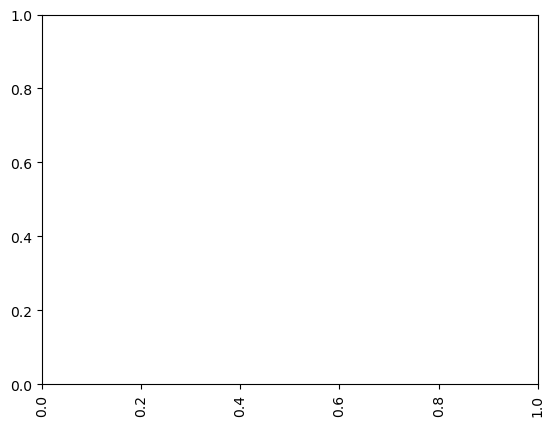

In [19]:

plt.xticks(rotation=90)


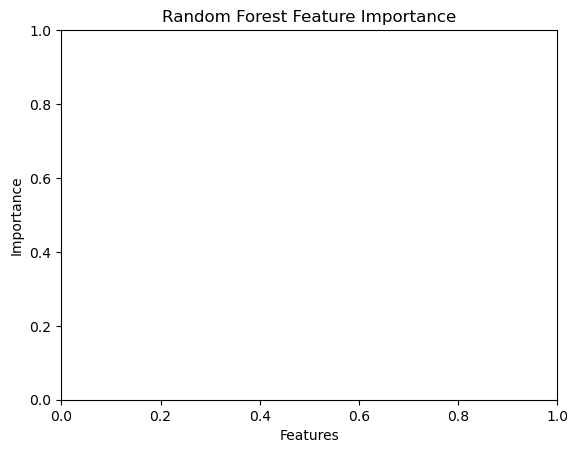

In [24]:

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Random Forest Feature Importance")

plt.show()

In [30]:

# Sort feature importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)


In [31]:

# Select top 8 features only
top_features = feature_importance.head(8)


In [32]:

# Create BIGGER graph
plt.figure(figsize=(16,8))


<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

<BarContainer object of 8 artists>

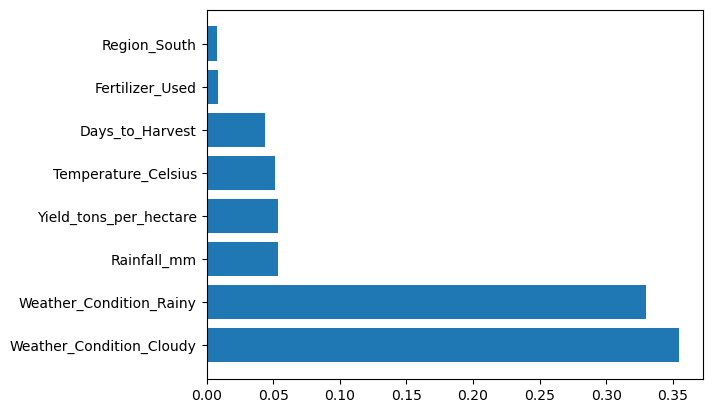

In [33]:

# Horizontal Bar Graph
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)


In [38]:
# Create bigger graph
plt.figure(figsize=(16,8))


<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

In [40]:
# -----------------------------
# SHORT FEATURE NAMES
# -----------------------------

short_names = [
    "Weather",
    "Condition",
    "Rainfall",
    "Temp",
    "Day",
    "Humidity",
    "Soil",
    "Region"
]


In [41]:

# Top 8 features
top_features = feature_importance.head(8)


In [42]:

plt.figure(figsize=(12,6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

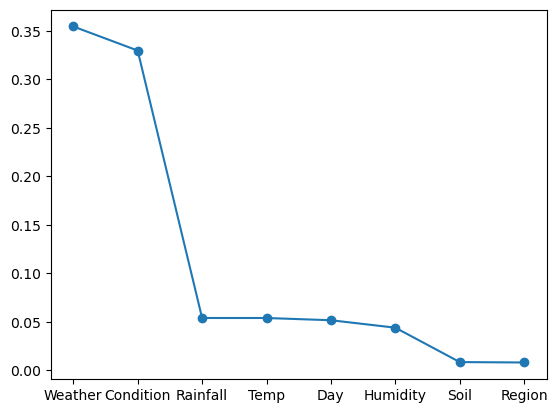

In [43]:

plt.plot(
    short_names,
    top_features['Importance'],
    marker='o'
)

<BarContainer object of 8 artists>

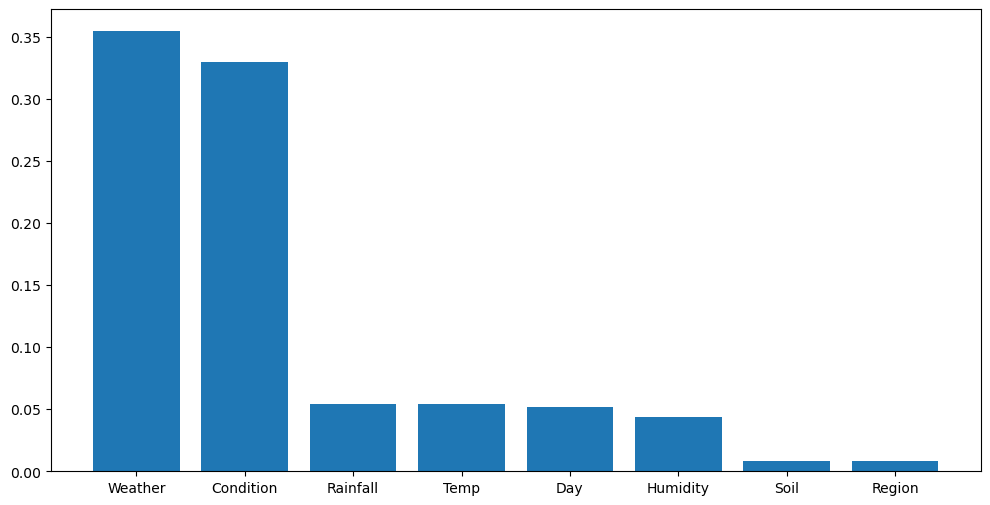

In [46]:
plt.figure(figsize=(12,6))

plt.bar(
    short_names,
    top_features['Importance']
)


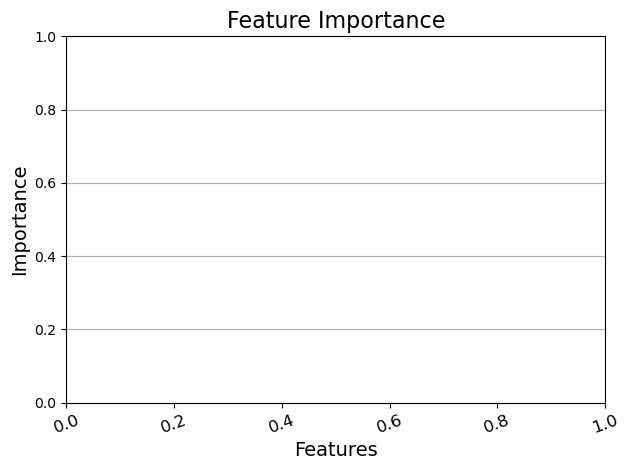

In [47]:

plt.xticks(rotation=20, fontsize=12)

plt.xlabel("Features", fontsize=14)
plt.ylabel("Importance", fontsize=14)

plt.title("Feature Importance", fontsize=16)

plt.grid(axis='y')

plt.tight_layout()

plt.show()